# Sentiment Analysis - LSTM Model

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Attention, Input, Softmax, Multiply, Lambda
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from nltk.stem import WordNetLemmatizer

In [78]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_utils import DataUtils
from models import train_lstm

In [79]:
models_output_dir = '../outputs/models/lstm'

In [80]:
import fasttext
import fasttext.util

# define the model file path
model_path = "../data/embeddings/cc.en.300.bin"

# download the FastText model if it does not exist
if not os.path.exists(model_path):
    fasttext.util.download_model('en', if_exists='ignore')  # download English FastText model (300D)

# load the FastText model
fasttext_model = fasttext.load_model(model_path)

In [81]:
# preprocess and tokenize data
def preprocess_data(df, max_length=128, vocab_size=10000):
    # initialize tokenizer and lemmatizer
    tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
    lemmatizer = WordNetLemmatizer()

    # remove missing or empty values
    df = df.dropna(subset=['Review']).copy()
    df = df[df['Review'].str.strip() != '']

    # extract texts and labels
    texts = df['Review'].astype(str).tolist()
    labels = df['Polarity'].values

    # apply lemmatization
    texts = [" ".join([lemmatizer.lemmatize(word) for word in text.split()]) for text in texts]

    # tokenize and pad sequences
    tokenizer.fit_on_texts(texts)
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

    return padded_sequences, np.array(labels), tokenizer

In [82]:
# preprocess and tokenize data using existing tokenizer
def tokenize_with_existing_tokenizer(df, tokenizer, max_length):
    texts = df['Review'].astype(str).tolist()
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    labels = df['Polarity'].values
    return padded_sequences, labels

In [83]:
def attention_layer(inputs):
    attention_weights = Dense(1, activation="tanh")(inputs)  # compute attention weights
    attention_weights = Softmax(axis=1)(attention_weights)  # normalize weights to [0,1]
    context_vector = Multiply()([inputs, attention_weights])  # multiply input by attention weights
    context_vector = Lambda(lambda x: tf.reduce_sum(x, axis=1))(context_vector)  # sum over the sequence
    return context_vector

In [84]:
def build_attention_lstm_model(vocab_size, embedding_dim, max_length, embedding_matrix, learning_rate=0.001):
    # define inputs
    inputs = Input(shape=(max_length,))
    
    # embedding layer
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=max_length, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # BiLSTM layer
    lstm_output = Bidirectional(LSTM(128, return_sequences=True))(embedding)  

    # attention layer
    attention_output = attention_layer(lstm_output)

    # fully connected layers
    dropout1 = Dropout(0.3)(attention_output)
    dense1 = Dense(64, activation='relu')(dropout1)
    dropout2 = Dropout(0.3)(dense1)
    outputs = Dense(1, activation='sigmoid')(dropout2)

    # define the model
    model = Model(inputs=inputs, outputs=outputs)

    # compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [85]:
def build_attention_lstm_model_yelp(vocab_size, embedding_dim, max_length, embedding_matrix, learning_rate=0.001):
    # define inputs
    inputs = Input(shape=(max_length,))
    
    # embedding layer
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=max_length, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # BiLSTM layers
    lstm_output = Bidirectional(LSTM(256, return_sequences=True))(embedding)  # Zwiększona liczba jednostek
    lstm_output = Bidirectional(LSTM(128, return_sequences=True))(lstm_output)  # Dodatkowa warstwa BiLSTM
    
    # attention layer
    attention_output = attention_layer(lstm_output)

    # fully connected layers
    dropout1 = Dropout(0.3)(attention_output)
    dense1 = Dense(128, activation='relu')(dropout1)  # Większa warstwa gęsta
    dropout2 = Dropout(0.3)(dense1)
    dense2 = Dense(64, activation='relu')(dropout2)  # Dodatkowa warstwa Dense
    dropout3 = Dropout(0.3)(dense2)
    outputs = Dense(1, activation='sigmoid')(dropout3)

    # define the model
    model = Model(inputs=inputs, outputs=outputs)

    # compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', metrics=['accuracy'])

    return model

# 1. LSTM Model - Amazon Books Reviews

## 1.1. Loading Data

In [86]:
# load the dataset
amazon_file = '../data/preprocessed/amazon.csv'
amazon_df = pd.read_csv(amazon_file, engine='python', encoding="ISO-8859-1")

In [87]:
# preview the data
amazon_df.head()

,Polarity,Review
0,0,As a Man Stinketh
1,1,MY FAVORITE!!
2,1,Epic novel
3,1,Very good source for Web Applications Development
4,1,Great fantasy


In [88]:
train_val_amazon_df, test_amazon_df = train_test_split(
    amazon_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=amazon_df['Polarity']
)

In [89]:
train_amazon_df, val_amazon_df = train_test_split(
    train_val_amazon_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_amazon_df['Polarity']
)

In [90]:
DataUtils.count_reviews_by_polarity(train_amazon_df)

Number of reviews with Polarity=1: 49382
Number of reviews with Polarity=0: 49382


In [91]:
DataUtils.count_reviews_by_polarity(val_amazon_df)

Number of reviews with Polarity=1: 10585
Number of reviews with Polarity=0: 10584


In [92]:
DataUtils.count_reviews_by_polarity(test_amazon_df)

Number of reviews with Polarity=1: 10582
Number of reviews with Polarity=0: 10583


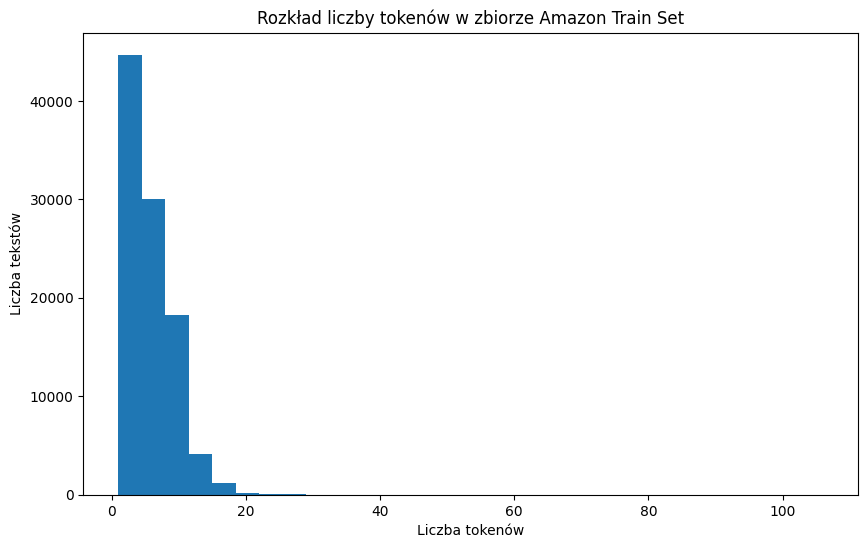

In [93]:
DataUtils.plot_token_distribution(train_amazon_df, "Amazon Train Set")

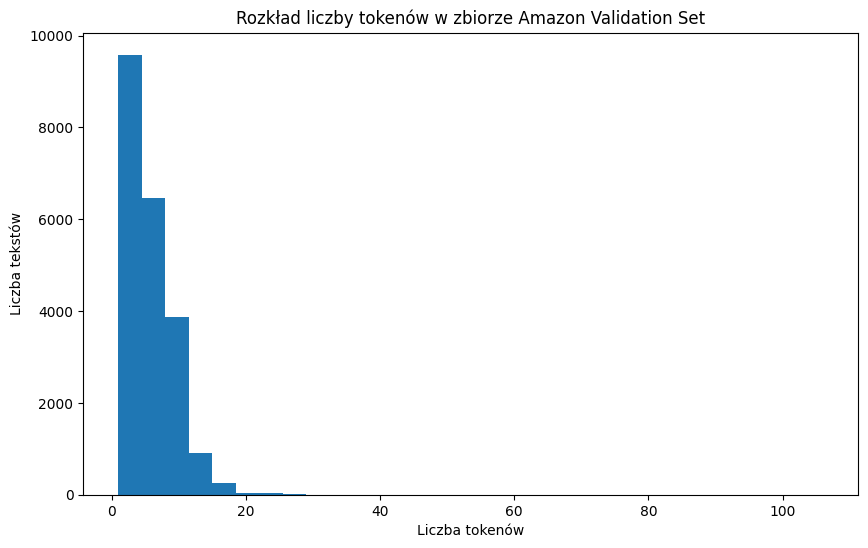

In [94]:
DataUtils.plot_token_distribution(val_amazon_df, "Amazon Validation Set")

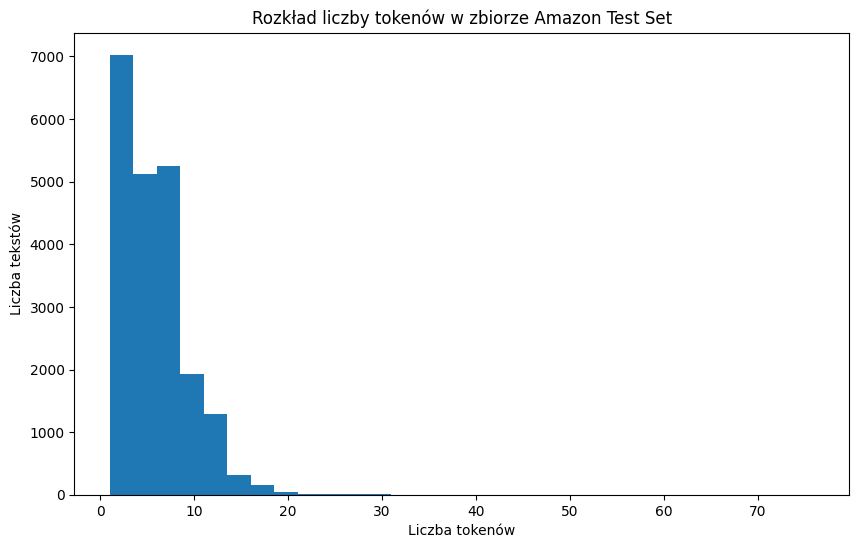

In [95]:
DataUtils.plot_token_distribution(test_amazon_df, "Amazon Test Set")

## 1.2. Data Preprocessing

In [96]:
# set preprocessing parameters
vocab_size = 12000  # maximum number of words in the tokenizer
max_length = 128  # maximum length of input sequences

In [97]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_amazon_df, max_length=max_length, vocab_size=vocab_size)

In [98]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_amazon_df, tokenizer, max_length)

In [99]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_amazon_df, tokenizer, max_length)

## 1.3. Model Training

In [100]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [101]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (12000, 300)


In [102]:
# define model architecture
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [103]:
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [104]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [105]:
# train the model
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 35s 11ms/step - loss: 0.6935 - accuracy: 0.5006 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 2/10
3087/3087 [==============================] - 33s 11ms/step - loss: 0.6932 - accuracy: 0.5007 - val_loss: 0.6935 - val_accuracy: 0.5000
Epoch 3/10
3087/3087 [==============================] - 34s 11ms/step - loss: 0.6934 - accuracy: 0.5035 - val_loss: 0.6934 - val_accuracy: 0.5000


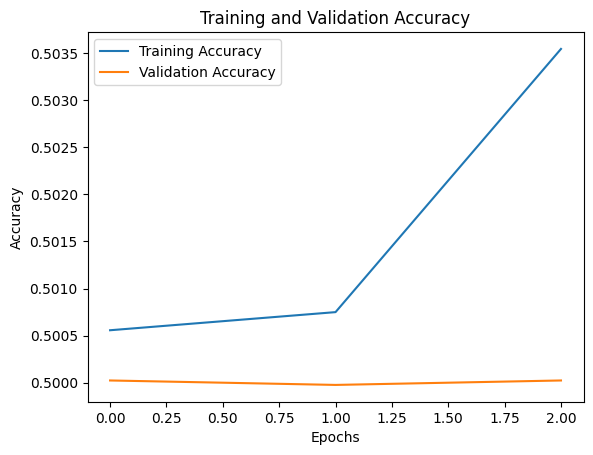

In [106]:
# plot accuracy on training and validation data
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

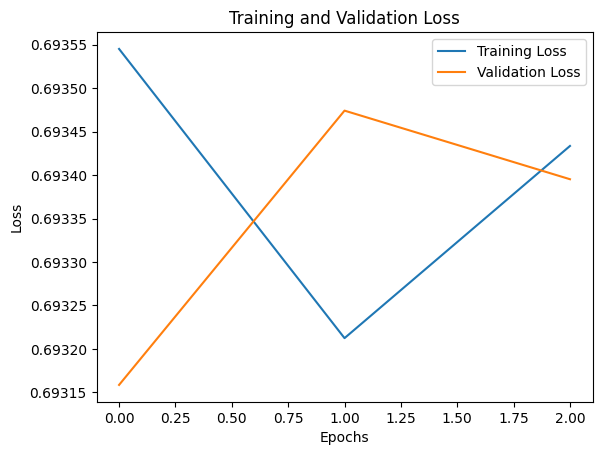

In [107]:
# plot loss on training and validation data
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [108]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_lstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 3s 4ms/step


KeyboardInterrupt: 

## 1.4. Searching for Best Model Parameters

### 1.4.1. BiLSTM

In [32]:

model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01))),
    Bidirectional(LSTM(64, kernel_regularizer=l2(0.01))),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [33]:
model_bilstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# train the model
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 86s 27ms/step - loss: 0.8189 - accuracy: 0.5005 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 2/10
3087/3087 [==============================] - 79s 26ms/step - loss: 0.6932 - accuracy: 0.4994 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/10
3087/3087 [==============================] - 79s 26ms/step - loss: 0.6932 - accuracy: 0.5015 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 4/10
3087/3087 [==============================] - 80s 26ms/step - loss: 0.6932 - accuracy: 0.4976 - val_loss: 0.6932 - val_accuracy: 0.5000


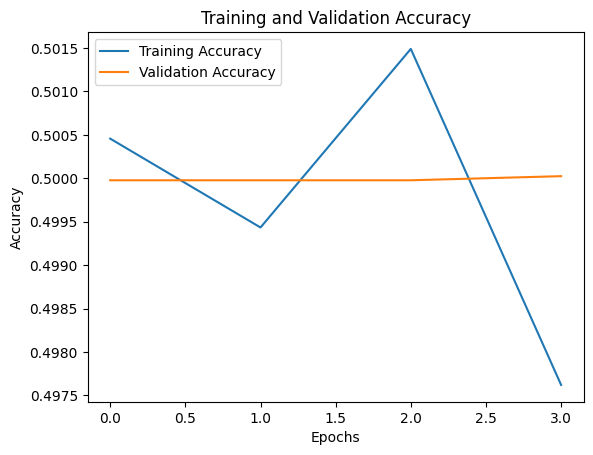

In [ ]:
# plot accuracy on training and validation data
plt.plot(history_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

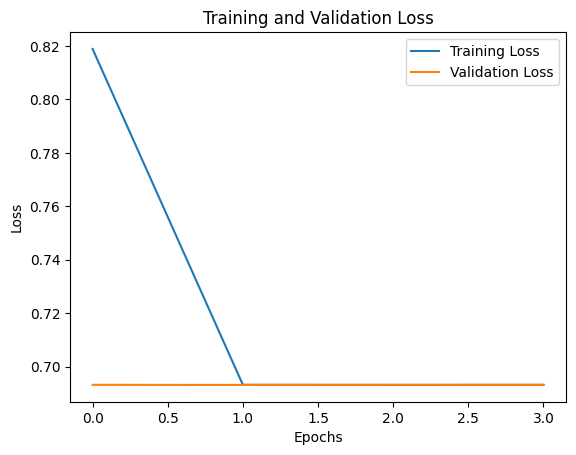

In [ ]:
# plot loss on training and validation data
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bilstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 8s 11ms/step
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     10584
           1       0.00      0.00      0.00     10585

    accuracy                           0.50     21169
   macro avg       0.25      0.50      0.33     21169
weighted avg       0.25      0.50      0.33     21169



c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in la

### 1.4.2. BiLSTM + Attention

In [38]:
model_attention = build_attention_lstm_model(vocab_size=vocab_size, embedding_dim=embedding_dim, max_length=max_length, embedding_matrix=embedding_matrix, learning_rate=learning_rate)

In [ ]:
# train the model
history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 59s 18ms/step - loss: 0.4986 - accuracy: 0.7507 - val_loss: 0.4257 - val_accuracy: 0.8008
Epoch 2/10
3087/3087 [==============================] - 56s 18ms/step - loss: 0.4085 - accuracy: 0.8096 - val_loss: 0.3932 - val_accuracy: 0.8159
Epoch 3/10
3087/3087 [==============================] - 55s 18ms/step - loss: 0.3847 - accuracy: 0.8199 - val_loss: 0.3856 - val_accuracy: 0.8178
Epoch 4/10
3087/3087 [==============================] - 56s 18ms/step - loss: 0.3716 - accuracy: 0.8273 - val_loss: 0.3813 - val_accuracy: 0.8150
Epoch 5/10
3087/3087 [==============================] - 59s 19ms/step - loss: 0.3657 - accuracy: 0.8309 - val_loss: 0.3689 - val_accuracy: 0.8286
Epoch 6/10
3087/3087 [==============================] - 56s 18ms/step - loss: 0.3509 - accuracy: 0.8363 - val_loss: 0.3689 - val_accuracy: 0.8263
Epoch 7/10
3087/3087 [==============================] - 56s 18ms/step - loss: 0.3381 - accuracy: 0.8432 - val_loss: 0.3648 -

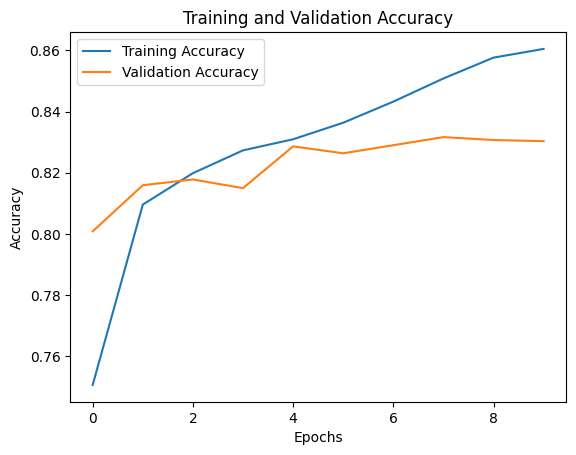

In [ ]:
# plot accuracy on training and validation data
plt.plot(history_attention.history['accuracy'], label='Training Accuracy')
plt.plot(history_attention.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

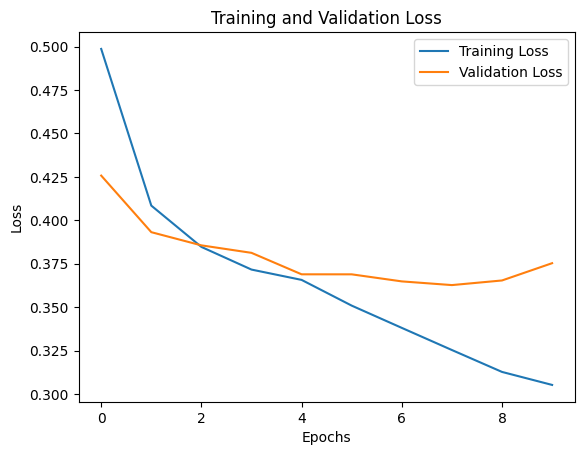

In [ ]:
# plot loss on training and validation data
plt.plot(history_attention.history['loss'], label='Training Loss')
plt.plot(history_attention.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_attention.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 5s 7ms/step
              precision    recall  f1-score   support

           0       0.84      0.83      0.83     10584
           1       0.83      0.84      0.83     10585

    accuracy                           0.83     21169
   macro avg       0.83      0.83      0.83     21169
weighted avg       0.83      0.83      0.83     21169



## 1.5. Model Evaluation on Test Data

In [43]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_amazon_df, max_length=max_length)

662/662 [==============================] - 5s 7ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.83      0.84      0.83     10583
           1       0.84      0.83      0.83     10582

    accuracy                           0.83     21165
   macro avg       0.83      0.83      0.83     21165
weighted avg       0.83      0.83      0.83     21165



## 1.6. Model Evaluation on Augmented Data

In [46]:
# load the augmented test sets
test_amazon_char_swap_file = '../data/preprocessed/amazon_test_char_swap.csv'
test_amazon_char_swap_df = pd.read_csv(test_amazon_char_swap_file, engine='python', encoding="ISO-8859-1")

test_amazon_embedding_file = '../data/preprocessed/amazon_test_embedding.csv'
test_amazon_embedding_df = pd.read_csv(test_amazon_embedding_file, engine='python', encoding="ISO-8859-1")

test_amazon_eda_file = '../data/preprocessed/amazon_test_eda.csv'
test_amazon_eda_df = pd.read_csv(test_amazon_eda_file, engine='python', encoding="ISO-8859-1")

In [ ]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_amazon_char_swap_df, max_length=max_length)

662/662 [==============================] - 5s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.75      0.76      0.75     10583
           1       0.76      0.74      0.75     10582

    accuracy                           0.75     21165
   macro avg       0.75      0.75      0.75     21165
weighted avg       0.75      0.75      0.75     21165



In [48]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_amazon_embedding_df, max_length=max_length)


662/662 [==============================] - 5s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.79      0.79      0.79     10583
           1       0.79      0.79      0.79     10582

    accuracy                           0.79     21165
   macro avg       0.79      0.79      0.79     21165
weighted avg       0.79      0.79      0.79     21165



In [49]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_amazon_eda_df, max_length=max_length)


662/662 [==============================] - 5s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     10583
           1       0.80      0.80      0.80     10582

    accuracy                           0.80     21165
   macro avg       0.80      0.80      0.80     21165
weighted avg       0.80      0.80      0.80     21165



## 1.7. Save Model

In [50]:
model_path = os.path.join(models_output_dir, "amazon_lstm_model.keras")
model_attention.save(model_path)

# 2. LSTM Model - Sentiment140

## 2.1. Loading Data

In [51]:
# load the dataset
sentiment140_file = '../data/preprocessed/sentiment140.csv'
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', encoding="ISO-8859-1")

In [52]:
# preview the data
sentiment140_df.head()

,Polarity,Review
0,1,@Alicia_86 srry u get my tweet?
1,1,@jchiarelli TTS to take text Tweets to the pho...
2,1,Mmmm apple cinnomin oatmeal
3,1,@willwallaceii thanks man. the truth can be fu...
4,1,RAIN The plants and trees are happy ^~^


In [53]:
train_val_sentiment140_df, test_sentiment140_df = train_test_split(
    sentiment140_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=sentiment140_df['Polarity']
)

In [54]:
train_sentiment140_df, val_sentiment140_df = train_test_split(
    train_val_sentiment140_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_sentiment140_df['Polarity']
)

In [55]:
DataUtils.count_reviews_by_polarity(train_sentiment140_df)

Number of reviews with Polarity=1: 111996
Number of reviews with Polarity=0: 111996


In [56]:
DataUtils.count_reviews_by_polarity(val_sentiment140_df)

Number of reviews with Polarity=1: 24004
Number of reviews with Polarity=0: 24004


In [57]:
DataUtils.count_reviews_by_polarity(test_sentiment140_df)

Number of reviews with Polarity=1: 24000
Number of reviews with Polarity=0: 24000


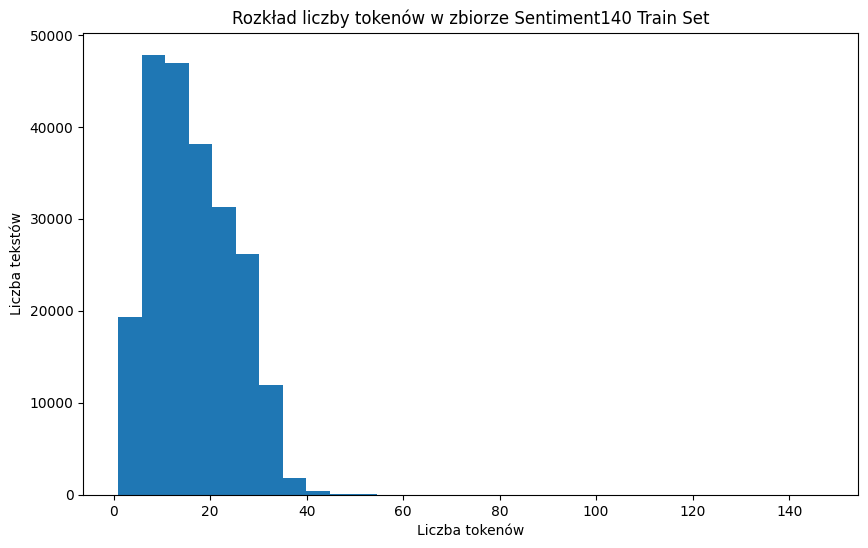

In [58]:
DataUtils.plot_token_distribution(train_sentiment140_df, "Sentiment140 Train Set")

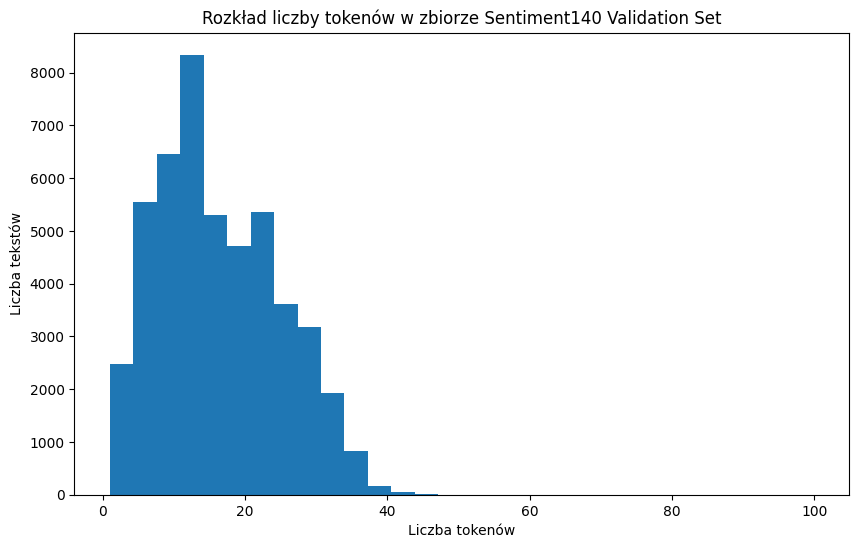

In [59]:
DataUtils.plot_token_distribution(val_sentiment140_df, "Sentiment140 Validation Set")

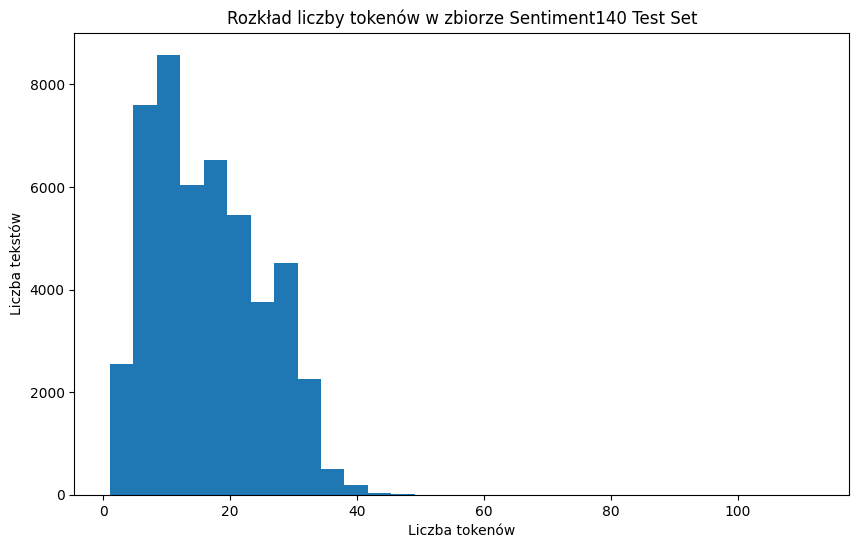

In [60]:
DataUtils.plot_token_distribution(test_sentiment140_df, "Sentiment140 Test Set")

## 2.2. Data Preprocessing

In [61]:
# set preprocessing parameters
vocab_size = 20000  # maximum number of words in the tokenizer
max_length = 128  # maximum length of input sequences

In [62]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_sentiment140_df, max_length=max_length, vocab_size=vocab_size)

In [63]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_sentiment140_df, tokenizer, max_length)

In [64]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_sentiment140_df, tokenizer, max_length)

## 2.3. Model Training

In [65]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [66]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (10000, 300)


In [67]:
# define model architecture
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [68]:
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [69]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [70]:
# train the model
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 86s 12ms/step - loss: 0.6933 - accuracy: 0.5002 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 2/10
7000/7000 [==============================] - 80s 11ms/step - loss: 0.6934 - accuracy: 0.5005 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 3/10
7000/7000 [==============================] - 80s 11ms/step - loss: 0.6932 - accuracy: 0.4993 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 4/10
7000/7000 [==============================] - 78s 11ms/step - loss: 0.6932 - accuracy: 0.5010 - val_loss: 0.6932 - val_accuracy: 0.5000


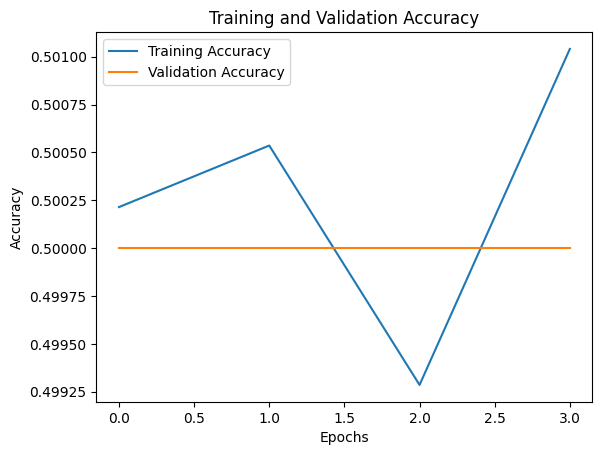

In [71]:
# plot accuracy on training and validation data
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

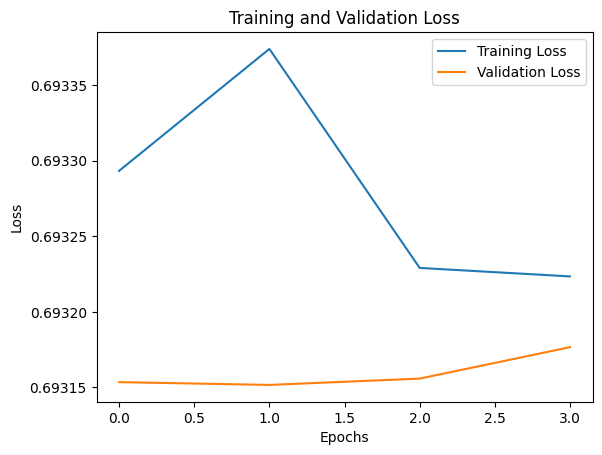

In [72]:
# plot loss on training and validation data
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [73]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_lstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 6s 4ms/step
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     24004
           1       0.00      0.00      0.00     24004

    accuracy                           0.50     48008
   macro avg       0.25      0.50      0.33     48008
weighted avg       0.25      0.50      0.33     48008



c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in la

## 2.4. Searching for Best Model Parameters

### 2.4.1. BiLSTM

In [74]:

model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01))),
    Bidirectional(LSTM(64, kernel_regularizer=l2(0.01))),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [75]:
model_bilstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [76]:
# train the model
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
5069/7000 [====================>.........] - ETA: 50s - loss: 0.7716 - accuracy: 0.5050

KeyboardInterrupt: 

In [ ]:
# plot accuracy on training and validation data
plt.plot(history_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [ ]:
# plot loss on training and validation data
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bilstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))

### 2.4.2. BiLSTM + Attention

In [ ]:
model_attention = build_attention_lstm_model(vocab_size=vocab_size, embedding_dim=embedding_dim, max_length=max_length, embedding_matrix=embedding_matrix, learning_rate=learning_rate)

In [ ]:
# train the model
history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

In [ ]:
# plot accuracy on training and validation data
plt.plot(history_attention.history['accuracy'], label='Training Accuracy')
plt.plot(history_attention.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [ ]:
# plot loss on training and validation data
plt.plot(history_attention.history['loss'], label='Training Loss')
plt.plot(history_attention.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_attention.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))

## 2.5. Model Evaluation on Test Data

In [ ]:
train_lstm.evaluate_model(model=model_lstm, tokenizer=tokenizer, test_df=test_sentiment140_df, max_length=max_length)

## 2.6. Model Evaluation on Augmented Data

In [ ]:
# load the augmented test sets
test_sentiment140_char_swap_file = '../data/preprocessed/sentiment140_test_char_swap.csv'
test_sentiment140_char_swap_df = pd.read_csv(test_sentiment140_char_swap_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_embedding_file = '../data/preprocessed/sentiment140_test_embedding.csv'
test_sentiment140_embedding_df = pd.read_csv(test_sentiment140_embedding_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_eda_file = '../data/preprocessed/sentiment140_test_eda.csv'
test_sentiment140_eda_df = pd.read_csv(test_sentiment140_eda_file, engine='python', encoding="ISO-8859-1")

In [ ]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_sentiment140_char_swap_df, max_length=max_length)

In [ ]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_sentiment140_embedding_df, max_length=max_length)


In [ ]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_sentiment140_eda_df, max_length=max_length)


## 2.7. Save Model

In [ ]:
model_path = os.path.join(models_output_dir, "sentiment140_lstm_model.keras")
model_attention.save(model_path)

# 3. LSTM Model - Yelp Reviews

## 3.1. Loading Data

In [ ]:
# load the dataset
yelp_file = '../data/preprocessed/yelp.csv'
yelp_df = pd.read_csv(yelp_file, engine='python', encoding="ISO-8859-1")

In [ ]:
# preview the data
yelp_df.head()

,Polarity,Review
0,0,As a Man Stinketh
1,1,MY FAVORITE!!
2,1,Epic novel
3,1,Very good source for Web Applications Development
4,1,Great fantasy


In [ ]:
train_val_yelp_df, test_yelp_df = train_test_split(
    yelp_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=yelp_df['Polarity']
)

In [ ]:
train_yelp_df, val_yelp_df = train_test_split(
    train_val_yelp_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_yelp_df['Polarity']
)

In [ ]:
DataUtils.count_reviews_by_polarity(train_yelp_df)

In [ ]:
DataUtils.count_reviews_by_polarity(val_yelp_df)

In [ ]:
DataUtils.count_reviews_by_polarity(test_yelp_df)

In [ ]:
DataUtils.plot_token_distribution(train_yelp_df, "Yelp Train Set")

In [ ]:
DataUtils.plot_token_distribution(val_yelp_df, "Yelp Validation Set")

In [ ]:
DataUtils.plot_token_distribution(test_yelp_df, "Yelp Test Set")

## 3.2. Data Preprocessing

In [ ]:
# set preprocessing parameters
vocab_size = 10000  # maximum number of words in the tokenizer
max_length = 256  # maximum length of input sequences

In [ ]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_yelp_df, max_length=max_length, vocab_size=vocab_size)

In [ ]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_yelp_df, tokenizer, max_length)

In [ ]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_yelp_df, tokenizer, max_length)

## 3.3. Model Training

In [ ]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [ ]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

In [ ]:
# define model architecture
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    LSTM(256, return_sequences=True), 
    Dropout(0.3),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    Dense(64, activation='relu'), 
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [ ]:
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
# train the model
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

In [ ]:
# plot accuracy on training and validation data
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [ ]:
# plot loss on training and validation data
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_lstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))

## 3.4. Searching for Best Model Parameters

### 3.4.1. BiLSTM

In [ ]:
model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    Bidirectional(LSTM(256, return_sequences=True, kernel_regularizer=l2(0.01))),  # Więcej jednostek
    Dropout(0.3),
    Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01))),  # Dodatkowa warstwa BiLSTM
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=False, kernel_regularizer=l2(0.01))),  
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),  # Więcej neuronów
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [ ]:
model_bilstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# train the model
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

In [ ]:
# plot accuracy on training and validation data
plt.plot(history_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [ ]:
# plot loss on training and validation data
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bilstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))

### 3.4.2. BiLSTM + Attention

In [ ]:
model_attention = build_attention_lstm_model_yelp(vocab_size=vocab_size, embedding_dim=embedding_dim, max_length=max_length, embedding_matrix=embedding_matrix, learning_rate=learning_rate)

In [ ]:
# train the model
history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

In [ ]:
# plot accuracy on training and validation data
plt.plot(history_attention.history['accuracy'], label='Training Accuracy')
plt.plot(history_attention.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [ ]:
# plot loss on training and validation data
plt.plot(history_attention.history['loss'], label='Training Loss')
plt.plot(history_attention.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_attention.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))

## 3.5. Model Evaluation on Test Data

In [ ]:
train_lstm.evaluate_model(model=model_lstm, tokenizer=tokenizer, test_df=test_yelp_df, max_length=max_length)

## 3.6. Model Evaluation on Augmented Data

In [ ]:
# load the augmented test sets
test_yelp_char_swap_file = '../data/preprocessed/yelp_test_char_swap.csv'
test_yelp_char_swap_df = pd.read_csv(test_yelp_char_swap_file, engine='python', encoding="ISO-8859-1")

test_yelp_transform_file = '../data/preprocessed/yelp_test_transform.csv'
test_yelp_transform_df = pd.read_csv(test_yelp_transform_file, engine='python', encoding="ISO-8859-1")

test_yelp_combined_file = '../data/preprocessed/yelp_test_combined.csv'
test_yelp_combined_df = pd.read_csv(test_yelp_combined_file, engine='python', encoding="ISO-8859-1")

In [ ]:
train_lstm.evaluate_model(model=model_lstm, tokenizer=tokenizer, test_df=test_yelp_char_swap_df, max_length=max_length)

In [ ]:
train_lstm.evaluate_model(model=model_lstm, tokenizer=tokenizer, test_df=test_yelp_transform_df, max_length=max_length)


In [ ]:
train_lstm.evaluate_model(model=model_lstm, tokenizer=tokenizer, test_df=test_yelp_combined_df, max_length=max_length)


## 3.7. Save Model

In [ ]:
model_path = os.path.join(models_output_dir, "yelp_lstm_model.keras")
model_lstm.save(model_path)